# EMG Data Analysis
Analysis of EMG (electromyography) readings across different actions and conditions.

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

## Discover CSV Files\nScan the data folders and extract a readable label from each filename.

In [64]:
data_dir = Path("data")

# Collect all CSVs from data/ and data/vs data/
csv_files = sorted(data_dir.rglob("*.csv"))

def label_from_filename(path):
    """Extract a human-readable label from the CSV filename."""
    name = path.stem  # e.g. "tc-2026-01-12_16-40-54-steated-resting"
    # Remove prefix (tc- or vs-) and the datetime portion
    label = re.sub(r"^(tc|vs)-\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}-", "", name)
    # Convert hyphens to spaces and title-case
    label = label.replace("-", " ").title()
    # Add prefix to distinguish sensor type
    prefix = "TC" if path.parts[0] == "data" and "vs" not in str(path) else "VS"
    if name.startswith("tc"):
        prefix = "TC"
    elif name.startswith("vs"):
        prefix = "VS"
    return f"[{prefix}] {label}"

# Build mapping: label -> path
file_labels = {label_from_filename(f): f for f in csv_files}

print(f"Found {len(file_labels)} CSV files:\n")
for i, (label, path) in enumerate(file_labels.items()):
    print(f"  {i+1:2d}. {label}  ({path.name})")

Found 4 CSV files:

   1. [TC] Standing Resting  (tc-2026-01-12_16-42-06-standing-resting.csv)
   2. [TC] Standing Holding  (tc-2026-01-12_16-43-16-standing-holding.csv)
   3. [TC] Standing Hammer Curl  (tc-2026-01-12_16-44-07-standing-hammer-curl.csv)
   4. [TC] Seated Thumbs Up  (tc-2026-01-12_16-46-28-seated-thumbs-up.csv)


## Select Files to Include
Set a file to `False` in the dictionary below to exclude it, then re-run the cells below.

In [67]:
# Set to False to exclude a file from the analysis
include = {label: True for label in file_labels}

# Print for reference
for label, included in include.items():
    status = "INCLUDE" if included else "EXCLUDE"
    print(f"  [{status}] {label}")

  [INCLUDE] [TC] Standing Resting
  [INCLUDE] [TC] Standing Holding
  [INCLUDE] [TC] Standing Hammer Curl
  [INCLUDE] [TC] Seated Thumbs Up


## Load Selected Data

In [70]:
selected_labels = [label for label, inc in include.items() if inc]
print(f"Loading {len(selected_labels)} file(s)...\n")

data = {}
for label in selected_labels:
    path = file_labels[label]
    df = pd.read_csv(path, header=None, names=["emg"])
    data[label] = df["emg"]
    print(f"  Loaded: {label} ({len(df)} samples)")

print(f"\nDone — {len(data)} datasets ready for plotting.")

Loading 4 file(s)...

  Loaded: [TC] Standing Resting (1000 samples)
  Loaded: [TC] Standing Holding (1000 samples)
  Loaded: [TC] Standing Hammer Curl (1000 samples)
  Loaded: [TC] Seated Thumbs Up (1000 samples)

Done — 4 datasets ready for plotting.


## EMG Readings Comparison\nAll selected datasets plotted on a single graph for easy comparison.

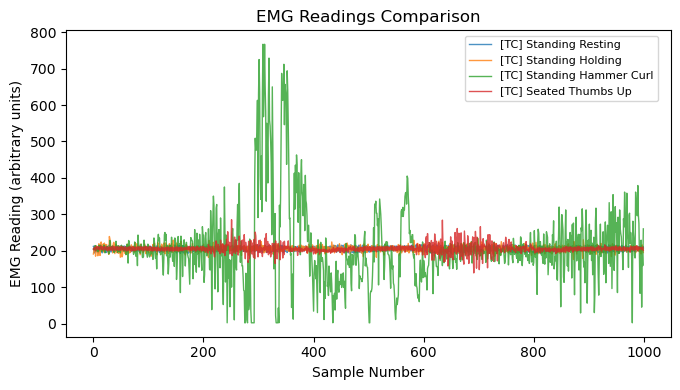

In [90]:
fig, ax = plt.subplots(figsize=(7, 4))

for label, series in data.items():
    ax.plot(series.values, label=label, alpha=0.8, linewidth=1)

ax.set_xlabel("Sample Number")
ax.set_ylabel("EMG Reading (arbitrary units)")
ax.set_title("EMG Readings Comparison")
ax.legend(bbox_to_anchor=(0.65, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig('emg_reading_comparison.png', dpi=600)
plt.show()

## Interpolation Comparison — Seated Thumbs Up
The original signal is downsampled, then reconstructed using three interpolation methods to compare their behaviour.

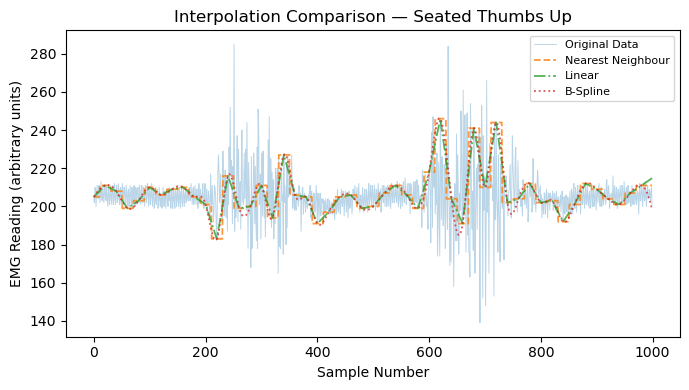

In [84]:
import numpy as np
from scipy.interpolate import interp1d, make_interp_spline

# Load the seated thumbs-up data
thumbs_path = data_dir / "tc-2026-01-12_16-46-28-seated-thumbs-up.csv"
thumbs = pd.read_csv(thumbs_path, header=None, names=["emg"])["emg"].values

# Full sample indices
x_full = np.arange(len(thumbs))

# Downsample: keep every 20th point
step = 20
x_down = x_full[::step]
y_down = thumbs[::step]

# Nearest-neighbour interpolation
nn_interp = interp1d(x_down, y_down, kind="nearest", fill_value="extrapolate")
y_nn = nn_interp(x_full)

# Linear interpolation
lin_interp = interp1d(x_down, y_down, kind="linear", fill_value="extrapolate")
y_lin = lin_interp(x_full)

# B-spline interpolation
bspline = make_interp_spline(x_down, y_down, k=3)
y_bspline = bspline(x_full)

# Plot
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_full, thumbs, label="Original Data", alpha=0.3, linewidth=0.7)
ax.plot(x_full, y_nn, label="Nearest Neighbour", alpha=0.8, linewidth=1.3, linestyle="--")
ax.plot(x_full, y_lin, label="Linear", alpha=0.8, linewidth=1.3, linestyle="-.")
ax.plot(x_full, y_bspline, label="B-Spline", alpha=0.8, linewidth=1.3, linestyle=":")

ax.set_xlabel("Sample Number")
ax.set_ylabel("EMG Reading (arbitrary units)")
ax.set_title("Interpolation Comparison — Seated Thumbs Up")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("emg_interpolation_comparison.png", dpi=600)
plt.show()

## Summary Statistics

In [78]:
stats = pd.DataFrame({
    label: series.describe()[["mean", "std", "min", "max"]]
    for label, series in data.items()
}).T
stats.columns = ["Mean", "Std Dev", "Min", "Max"]
stats.index.name = "Dataset"
stats.round(2)

,Mean,Std Dev,Min,Max
Dataset,,,,
[TC] Standing Resting,205.28,6.55,193.0,217.0
[TC] Standing Holding,205.32,8.50,176.0,239.0
[TC] Standing Hammer Curl,210.70,107.84,2.0,767.0
[TC] Seated Thumbs Up,205.55,12.57,139.0,285.0
